# Nihai LSTM ve GRU Test Değerlendirmesi

Bu notebook, `results/EXPERIMENT_SELECTION.md` dosyasında dondurulan protokolü uygular. LSTM ve GRU validation ile seçilen ağırlıklarıyla değiştirilmemiş test döneminde bir kez değerlendirilir. Test sonuçları hiperparametre ayarlamak için kullanılmaz.

In [1]:
import copy
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from torch import nn
from torch.optim import Adam

from ms_stock_prediction.models import GRUModel, LSTMModel, count_trainable_parameters
from ms_stock_prediction.preprocessing import (
    PreparationConfig,
    load_close_prices,
    prepare_time_series,
)
from ms_stock_prediction.training import evaluate_loss, train_one_epoch

SEED = 42
EPOCHS = 100
LEARNING_RATE = 0.001
LOOKBACK = 20
HIDDEN_SIZE = 32
NUM_LAYERS = 2
BATCH_SIZE = 32
DEVICE = torch.device("cpu")

EXPECTED_VALIDATION_RMSE = {"LSTM": 5.4265, "GRU": 6.1166}
VALIDATION_TOLERANCE = 0.001

pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
plt.style.use("seaborn-v0_8-whitegrid")

## Dondurulan protokol

- Kronolojik `%70 train / %15 validation / %15 test`
- Train döneminde uydurulan MinMaxScaler `[-1, 1]`
- 20 günlük lookback, 32 gizli birim, 2 katman
- Adam `0.001`, MSE loss, 100 epoch, seed `42`
- En düşük validation MSE değerindeki ağırlıkların seçimi
- LSTM, GRU ve naive baseline için aynı test hedefleri

In [2]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / "pyproject.toml").exists():
    raise FileNotFoundError("Proje kökü bulunamadı. Notebook'u proje içinde çalıştırın.")

DATA_PATH = PROJECT_ROOT / "data/raw/msft_daily_latest.csv"
MODEL_DIR = PROJECT_ROOT / "models"
prices = load_close_prices(DATA_PATH)
config = PreparationConfig(
    lookback=LOOKBACK,
    batch_size=BATCH_SIZE,
    shuffle_seed=SEED,
)

print(f"Kapanış fiyatı gözlemi: {len(prices):,}")
print(f"Veri tarih aralığı: {prices.index.min().date()} - {prices.index.max().date()}")

Kapanış fiyatı gözlemi: 4,156
Veri tarih aralığı: 2010-01-04 - 2026-07-14


In [3]:
def regression_metrics(actual, predicted):
    errors = predicted - actual
    mse = float(np.mean(errors**2))
    return {
        "MSE (USD²)": mse,
        "RMSE (USD)": float(np.sqrt(mse)),
        "MAE (USD)": float(np.mean(np.abs(errors))),
    }


def predict_usd(model, inputs, targets, scaler):
    model.eval()
    with torch.no_grad():
        predicted_scaled = model(inputs.to(DEVICE)).cpu().numpy()
    actual_scaled = targets.numpy()
    predicted_usd = scaler.inverse_transform(predicted_scaled).ravel()
    actual_usd = scaler.inverse_transform(actual_scaled).ravel()
    return predicted_usd, actual_usd


def train_selected_model(model_class, model_name):
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    prepared = prepare_time_series(prices, config)
    model = model_class(
        input_size=1,
        hidden_size=HIDDEN_SIZE,
        num_layers=NUM_LAYERS,
        output_size=1,
    ).to(DEVICE)
    loss_function = nn.MSELoss()
    optimizer = Adam(model.parameters(), lr=LEARNING_RATE)

    history = []
    best_validation_loss = float("inf")
    best_epoch = 0
    best_model_state = None
    training_started = time.perf_counter()

    for epoch in range(1, EPOCHS + 1):
        train_loss = train_one_epoch(
            model, prepared.train_loader, optimizer, loss_function, DEVICE
        )
        validation_loss = evaluate_loss(
            model, prepared.validation_loader, loss_function, DEVICE
        )
        history.append(
            {
                "Epoch": epoch,
                "Train MSE (scaled)": train_loss,
                "Validation MSE (scaled)": validation_loss,
            }
        )

        if validation_loss < best_validation_loss:
            best_validation_loss = validation_loss
            best_epoch = epoch
            best_model_state = copy.deepcopy(model.state_dict())

        if epoch == 1 or epoch % 10 == 0:
            print(
                f"{model_name} | epoch {epoch:03d}/{EPOCHS} | "
                f"train={train_loss:.6f} | validation={validation_loss:.6f}"
            )

    training_seconds = time.perf_counter() - training_started
    if best_model_state is None:
        raise RuntimeError("Eğitim sırasında geçerli model ağırlığı üretilemedi.")
    model.load_state_dict(best_model_state)

    validation_prediction, validation_actual = predict_usd(
        model, prepared.X_validation, prepared.y_validation, prepared.scaler
    )
    validation_metrics = regression_metrics(validation_actual, validation_prediction)

    outcome = {
        "Model": model_name,
        "Seçilen epoch": best_epoch,
        **validation_metrics,
        "Parametre": count_trainable_parameters(model),
        "Eğitim süresi (sn)": training_seconds,
    }

    return {
        "model": model,
        "prepared": prepared,
        "history": pd.DataFrame(history).set_index("Epoch"),
        "validation_outcome": outcome,
    }

## Dondurulan modellerin eğitimi

Bu bölüm yalnızca train verisiyle ağırlıkları günceller ve validation verisiyle en iyi epoch'u seçer. Test tensorları kullanılmaz.

In [4]:
lstm_artifacts = train_selected_model(LSTMModel, "LSTM")
gru_artifacts = train_selected_model(GRUModel, "GRU")

lstm_prepared = lstm_artifacts["prepared"]
gru_prepared = gru_artifacts["prepared"]
assert lstm_prepared.validation_target_dates.equals(
    gru_prepared.validation_target_dates
)
assert lstm_prepared.test_target_dates.equals(gru_prepared.test_target_dates)
assert torch.equal(lstm_prepared.X_train, gru_prepared.X_train)

LSTM | epoch 001/100 | train=0.141562 | validation=0.336362


LSTM | epoch 010/100 | train=0.000513 | validation=0.020909


LSTM | epoch 020/100 | train=0.000420 | validation=0.006453


LSTM | epoch 030/100 | train=0.000328 | validation=0.004541


LSTM | epoch 040/100 | train=0.000311 | validation=0.006775


...

GRU | epoch 060/100 | train=0.000185 | validation=0.002871


GRU | epoch 070/100 | train=0.000185 | validation=0.002690


GRU | epoch 080/100 | train=0.000189 | validation=0.002280


GRU | epoch 090/100 | train=0.000196 | validation=0.002606


GRU | epoch 100/100 | train=0.000187 | validation=0.002792


## Validation yeniden üretilebilirlik kapısı

Test değerlendirmesinden önce iki modelin dondurulan validation RMSE değerlerini tolerans içinde yeniden üretmesi gerekir. Bu kontrol başarısız olursa notebook burada durur.

In [5]:
validation_results = pd.DataFrame(
    [
        lstm_artifacts["validation_outcome"],
        gru_artifacts["validation_outcome"],
    ]
).set_index("Model")
display(validation_results)

for model_name, expected_rmse in EXPECTED_VALIDATION_RMSE.items():
    observed_rmse = validation_results.loc[model_name, "RMSE (USD)"]
    assert np.isclose(
        observed_rmse, expected_rmse, atol=VALIDATION_TOLERANCE
    ), f"{model_name} validation RMSE dondurulan sonucu yeniden üretmedi."

print("Validation kapısı geçti; dondurulan deney sonuçları yeniden üretildi.")

,Seçilen epoch,MSE (USD²),RMSE (USD),MAE (USD),Parametre,Eğitim süresi (sn)
Model,,,,,,
LSTM,96,29.4468,5.4265,4.2340,12961,36.1125
GRU,72,37.4128,6.1166,4.8147,9729,118.8495


Validation kapısı geçti; dondurulan deney sonuçları yeniden üretildi.


In [6]:
MODEL_DIR.mkdir(parents=True, exist_ok=True)
saved_model_paths = []

for model_name, artifacts in [
    ("LSTM", lstm_artifacts),
    ("GRU", gru_artifacts),
]:
    prepared = artifacts["prepared"]
    outcome = artifacts["validation_outcome"]
    checkpoint_path = MODEL_DIR / f"{model_name.lower()}_selected.pt"
    torch.save(
        {
            "model_name": model_name,
            "model_state_dict": artifacts["model"].state_dict(),
            "selected_epoch": int(outcome["Seçilen epoch"]),
            "seed": SEED,
            "lookback": LOOKBACK,
            "hidden_size": HIDDEN_SIZE,
            "num_layers": NUM_LAYERS,
            "learning_rate": LEARNING_RATE,
            "scaler_min": prepared.scaler.min_.tolist(),
            "scaler_scale": prepared.scaler.scale_.tolist(),
            "scaler_data_min": prepared.scaler.data_min_.tolist(),
            "scaler_data_max": prepared.scaler.data_max_.tolist(),
        },
        checkpoint_path,
    )
    saved_model_paths.append(checkpoint_path)

for path in saved_model_paths:
    print(f"Yerel model ağırlığı: {path}")

Yerel model ağırlığı: C:\Users\brkbs\Desktop\Stock_Price_Prediction\models\lstm_selected.pt
Yerel model ağırlığı: C:\Users\brkbs\Desktop\Stock_Price_Prediction\models\gru_selected.pt


## Nihai test değerlendirmesi

Validation kapısı geçtikten sonra değiştirilmemiş test dönemi burada ilk kez model tahmini için kullanılır. Bu bölümde ağırlık güncellemesi veya hiperparametre seçimi yapılmaz.

In [7]:
test_predictions = {}
test_outcomes = []
test_actual_reference = None

for model_name, artifacts in [
    ("LSTM", lstm_artifacts),
    ("GRU", gru_artifacts),
]:
    prepared = artifacts["prepared"]
    prediction, actual = predict_usd(
        artifacts["model"], prepared.X_test, prepared.y_test, prepared.scaler
    )
    if test_actual_reference is None:
        test_actual_reference = actual
    else:
        assert np.array_equal(test_actual_reference, actual)
    test_predictions[model_name] = prediction
    test_outcomes.append(
        {
            "Model": model_name,
            **regression_metrics(actual, prediction),
            "Parametre": count_trainable_parameters(artifacts["model"]),
            "Seçilen epoch": artifacts["validation_outcome"]["Seçilen epoch"],
            "Eğitim süresi (sn)": artifacts["validation_outcome"]["Eğitim süresi (sn)"],
        }
    )

naive_test_scaled = lstm_prepared.X_test[:, -1, 0].numpy().reshape(-1, 1)
naive_test_usd = lstm_prepared.scaler.inverse_transform(naive_test_scaled).ravel()
test_predictions["Naive baseline"] = naive_test_usd
test_outcomes.append(
    {
        "Model": "Naive baseline",
        **regression_metrics(test_actual_reference, naive_test_usd),
        "Parametre": 0,
        "Seçilen epoch": np.nan,
        "Eğitim süresi (sn)": np.nan,
    }
)

test_results = pd.DataFrame(test_outcomes).set_index("Model")
display(test_results)

,MSE (USD²),RMSE (USD),MAE (USD),Parametre,Seçilen epoch,Eğitim süresi (sn)
Model,,,,,,
LSTM,436.1931,20.8852,15.2420,12961,96.0000,36.1125
GRU,"1,376.3479",37.0992,32.0546,9729,72.0000,118.8495
Naive baseline,44.2748,6.6539,4.6795,0,NaN,NaN


In [8]:
test_dates = lstm_prepared.test_target_dates
assert len(test_dates) == len(test_actual_reference) == 624
assert lstm_prepared.validation_target_dates.max() < test_dates.min()
assert np.isfinite(test_results[["MSE (USD²)", "RMSE (USD)", "MAE (USD)"]].to_numpy()).all()
assert all(np.isfinite(prediction).all() for prediction in test_predictions.values())

print(f"Test hedefi: {len(test_dates):,}")
print(f"Test tarihleri: {test_dates.min().date()} - {test_dates.max().date()}")
print("Test metrikleri yalnızca dondurulan modellerin nihai raporu için hesaplandı.")

Test hedefi: 624
Test tarihleri: 2024-01-17 - 2026-07-14
Test metrikleri yalnızca dondurulan modellerin nihai raporu için hesaplandı.


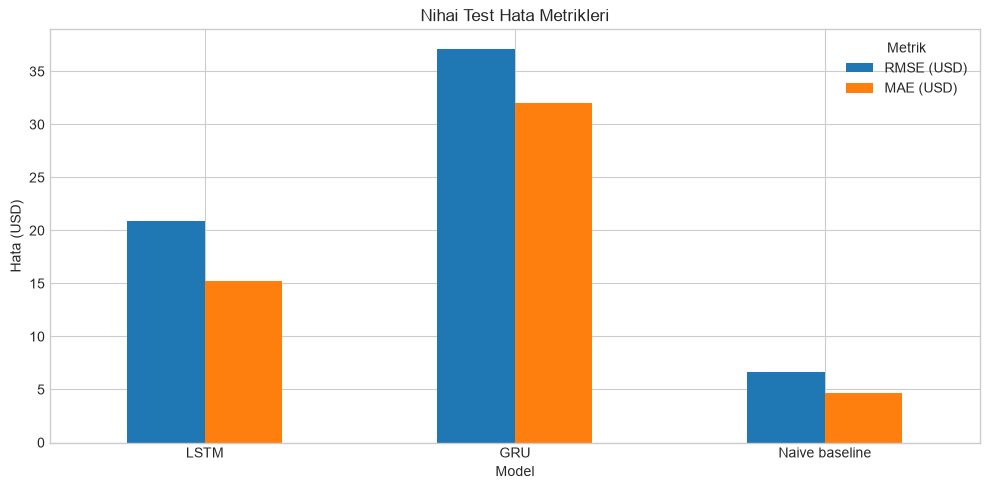

In [9]:
ax = test_results[["RMSE (USD)", "MAE (USD)"]].plot(
    kind="bar", figsize=(10, 5), rot=0
)
ax.set_title("Nihai Test Hata Metrikleri")
ax.set_xlabel("Model")
ax.set_ylabel("Hata (USD)")
ax.legend(title="Metrik")
plt.tight_layout()
plt.show()

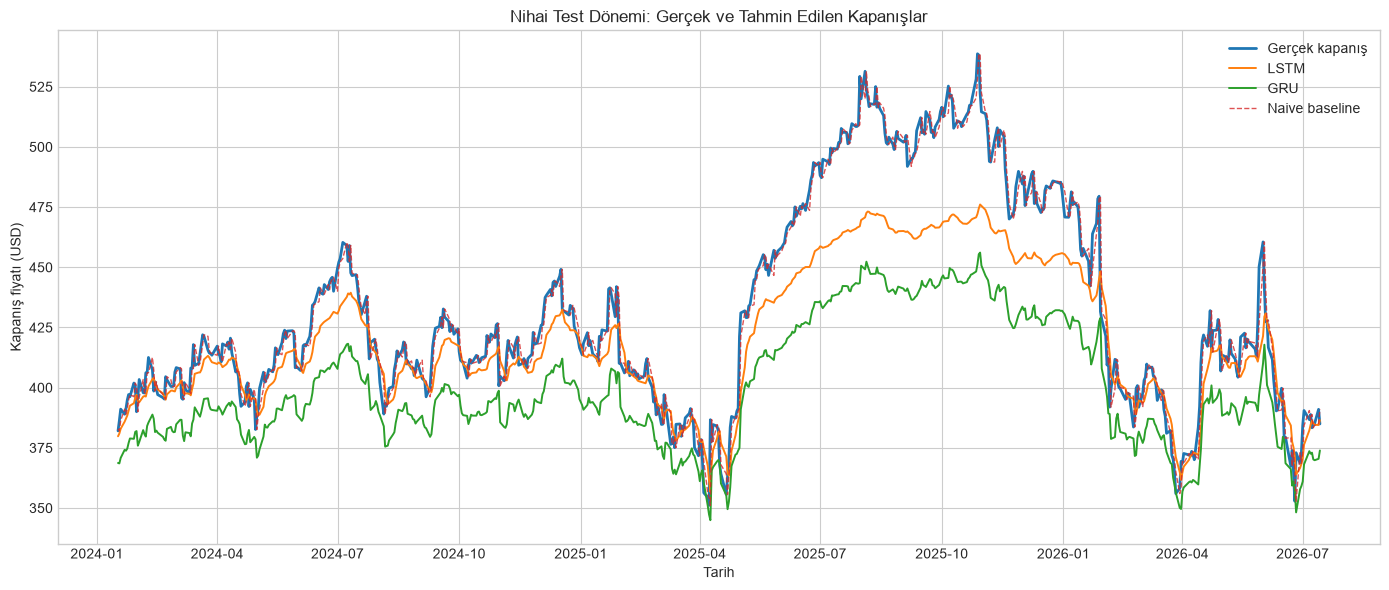

In [10]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(test_dates, test_actual_reference, label="Gerçek kapanış", linewidth=2)
ax.plot(test_dates, test_predictions["LSTM"], label="LSTM", linewidth=1.4)
ax.plot(test_dates, test_predictions["GRU"], label="GRU", linewidth=1.4)
ax.plot(
    test_dates,
    test_predictions["Naive baseline"],
    label="Naive baseline",
    linewidth=1,
    linestyle="--",
    alpha=0.8,
)
ax.set_title("Nihai Test Dönemi: Gerçek ve Tahmin Edilen Kapanışlar")
ax.set_xlabel("Tarih")
ax.set_ylabel("Kapanış fiyatı (USD)")
ax.legend()
plt.tight_layout()
plt.show()

## Nihai bulgular

Aşağıdaki özet yalnızca dondurulan deney protokolünün test performansını raporlar.

In [11]:
best_model_name = test_results["RMSE (USD)"].idxmin()
best_rmse = test_results.loc[best_model_name, "RMSE (USD)"]
lstm_gru_difference = (
    test_results.loc["LSTM", "RMSE (USD)"]
    - test_results.loc["GRU", "RMSE (USD)"]
)

print(f"En düşük nihai test RMSE: {best_model_name} ({best_rmse:.4f} USD)")
print(f"LSTM - GRU test RMSE farkı: {lstm_gru_difference:+.4f} USD")
print("Bu test sonuçları hiperparametre seçmek veya yeniden eğitim kararı vermek için kullanılmayacaktır.")

En düşük nihai test RMSE: Naive baseline (6.6539 USD)
LSTM - GRU test RMSE farkı: -16.2139 USD
Bu test sonuçları hiperparametre seçmek veya yeniden eğitim kararı vermek için kullanılmayacaktır.
